# 46b · autoimmune diseases · bulk_RNA_seq · patterns relative to healthy children

Reads `autoimmune_vs_healthy.rds` and the `top_genes_<disease>_vs_<healthy block>.csv` files of notebook 46.
Writes `patterns_vs_<healthy block>.csv` in `data/run_artifacts/CANDLE_SAVI/` and figures to
`figures/CANDLE_SAVI/`.

**Objective.** Pattern discovery across the five autoimmune diseases (AGS, CANDLE, SAVI, UAID, SLE), relative to
healthy children:
1. **Genes.** Which genes differ from healthy children in all five diseases, in several, or in one only.
2. **Patients.** How the disease samples group by their genes' difference from healthy children.

**The lab caveat.** In notebook 46 about three quarters of the genes differ between each disease and the healthy
children. The healthy children were sequenced in one lab and every disease sample in others, so a pattern shared
by all five diseases may be a disease pattern or the lab difference; these data cannot tell the two apart. The
interferon response genes, whose rise in these diseases is known, are marked in the results as the check.

## Read the results of notebook 46

In [1]:
source("../src/paths.R")
suppressMessages({library(ComplexHeatmap); library(circlize)})
a  <- readRDS(art("CANDLE_SAVI", "autoimmune_vs_healthy.rds"))
dz <- c("AGS", "CANDLE", "SAVI", "UAID", "SLE"); hb <- c("healthy_under2", "healthy_2plus")
top <- lapply(setNames(hb, hb), function(h) lapply(setNames(dz, dz), function(d)
  read.csv(art("CANDLE_SAVI", sprintf("top_genes_%s_vs_%s.csv", d, h)))))
sapply(top, function(l) sapply(l, nrow))

,healthy_under2,healthy_2plus
AGS,8728,8665
CANDLE,9314,9147
SAVI,8983,8819
UAID,9266,9129
SLE,4165,4005


**Explanation**
- `a` holds the sample table, the display values (log2 counts per million), the gene names and the interferon
  gene table of notebook 46.
- `top` reads, for each healthy block and each disease, the top genes against healthy (adjusted p < 0.05, fold
  change at least 2); the table counts them.

**Result.** Against healthy children under 2 / aged 2 or older: AGS 8,728 / 8,665 top genes, CANDLE 9,314 / 9,147,
SAVI 8,983 / 8,819, UAID 9,266 / 9,129, SLE 4,165 / 4,005.

## 1. Shared and distinct genes

In [2]:
pattern_table <- function(h) {
  g <- unique(unlist(lapply(top[[h]], `[[`, "gene_id")))
  dir <- sapply(dz, function(d) { t <- top[[h]][[d]]; s <- sign(t$logFC)[match(g, t$gene_id)]; ifelse(is.na(s), 0, s) })
  rownames(dir) <- g
  up   <- apply(dir, 1, function(r) paste(dz[r > 0], collapse = "+"))
  down <- apply(dir, 1, function(r) paste(dz[r < 0], collapse = "+"))
  data.frame(gene_id = g, gene_name = a$genes$gene_name[match(g, a$genes$gene_id)], dir,
             n_up = rowSums(dir > 0), n_down = rowSums(dir < 0), up_in = up, down_in = down,
             interferon_response_gene = g %in% a$ifn$gene_id[a$ifn$set == "IRG-28"], row.names = NULL)
}
pt <- lapply(setNames(hb, hb), pattern_table)
for (h in hb) write.csv(pt[[h]], art("CANDLE_SAVI", sprintf("patterns_vs_%s.csv", h)), row.names = FALSE)
t(sapply(pt, function(p) c(genes = nrow(p), up_in_all_5 = sum(p$n_up == 5), down_in_all_5 = sum(p$n_down == 5),
  up_in_4 = sum(p$n_up == 4), down_in_4 = sum(p$n_down == 4), up_in_1_only = sum(p$n_up == 1 & p$n_down == 0),
  down_in_1_only = sum(p$n_down == 1 & p$n_up == 0), opposite_directions = sum(p$n_up > 0 & p$n_down > 0),
  interferon_genes_up_in_all_5 = sum(p$n_up == 5 & p$interferon_response_gene))))

,genes,up_in_all_5,down_in_all_5,up_in_4,down_in_4,up_in_1_only,down_in_1_only,opposite_directions,interferon_genes_up_in_all_5
healthy_under2,11188,857,1127,3494,2558,779,751,780,3
healthy_2plus,11055,800,998,3497,2592,767,740,807,10


**Explanation**
- `pattern_table(h)` takes the genes in any of the five top lists against healthy block `h`:
  - `dir` holds, for each gene and disease, +1 if the gene is a top gene up in that disease, -1 if down, 0 if
    it is not a top gene;
  - `up_in` and `down_in` name the diseases in which the gene is up or down, for example `CANDLE+SAVI+UAID`;
  - `n_up` and `n_down` count them; `interferon_response_gene` marks the 28 interferon response genes.
- `patterns_vs_<healthy block>.csv` keeps the table, one row per gene (for enrichment analysis).
- The summary counts the genes up or down in all five diseases, in four, in one only, the genes that go up in
  some diseases and down in others, and the interferon response genes up in all five.

**Result.** Against healthy children aged 2 or older (under 2 in brackets): 11,055 (11,188) genes are top genes in at
least one disease; 800 (857) are up and 998 (1,127) down in all five diseases; 3,497 (3,494) are up and 2,592
(2,558) down in four. 10 (3) of the 28 interferon response genes are up in all five: HERC6, DDX60, EPSTI1,
SPATS2L, IFI44L, USP18, HERC5, IFI44, IFI27 and RSAD2 against healthy children aged 2 or older.

**The most common combinations** (an UpSet-style table: the number of genes for each combination of diseases).

In [3]:
combos <- function(p) {
  u <- sort(table(p$up_in[p$n_up > 0 & p$n_down == 0]), decreasing = TRUE)
  d <- sort(table(p$down_in[p$n_down > 0 & p$n_up == 0]), decreasing = TRUE)
  list(up = head(data.frame(diseases = names(u), genes = as.integer(u)), 12),
       down = head(data.frame(diseases = names(d), genes = as.integer(d)), 12))
}
combos(pt$healthy_2plus)

,diseases,genes
,<chr>,<int>
1,AGS+CANDLE+SAVI+UAID,3000
2,AGS+CANDLE+SAVI+UAID+SLE,800
3,SLE,484
4,CANDLE+SAVI+UAID,243
5,AGS,109
6,CANDLE+SAVI+UAID+SLE,103
7,CANDLE,84
8,AGS+CANDLE+UAID,74
9,CANDLE+UAID,70


**Explanation**
- `combos(p)` counts the genes for each combination of diseases in which they are up (only up) or down (only
  down), and lists the 12 largest of each, against healthy children aged 2 or older. The same table against
  healthy children under 2 is in `patterns_vs_healthy_under2.csv`.

**Result.** The largest combination is the four internal diseases without SLE: 3,000 genes up and 2,315 down in
AGS, CANDLE, SAVI and UAID only. Next come the five diseases together (800 up, 998 down) and SLE alone (484
up, 449 down). The four internal diseases were sequenced at the same four facilities and SLE in another lab, so
the largest combinations follow the source of the samples as much as the disease.

**Genes that set one disease apart** (top genes up or down in one disease only, the 10 with the largest log2 fold
change), against healthy children aged 2 or older.

In [4]:
p <- pt$healthy_2plus
for (d in dz) {
  t <- top$healthy_2plus[[d]]
  one <- t[t$gene_id %in% p$gene_id[(p$n_up + p$n_down) == 1 & p[[d]] != 0], ]
  one <- head(one[order(-abs(one$logFC)), c("gene_name", "logFC", "adj.P.Val")], 10)
  cat("\n", d, ": ", sum((p$n_up + p$n_down) == 1 & p[[d]] != 0), " genes in this disease only\n", sep = "")
  print(transform(one, logFC = round(logFC, 2), adj.P.Val = signif(adj.P.Val, 2)), row.names = FALSE)
}


AGS: 258 genes in this disease only
 gene_name logFC adj.P.Val
     CD177 -4.01   0.02400
     SEPT4 -3.50   0.00053
      IRG1 -2.93   0.00031
      AOC1 -2.89   0.01600
     PRRT4 -2.79   0.00110
     ZMAT4  2.54   0.00063
     CLRN1 -2.25   0.01300
      NRN1 -2.24   0.01600
     GPR84 -2.23   0.00390
     LRRN3  2.15   0.00038

CANDLE: 147 genes in this disease only
 gene_name logFC adj.P.Val
      PAX8 -2.70   7.0e-03
    TREML4 -2.45   3.7e-02
      GBP6  2.42   1.1e-03
     FOXO6 -2.05   1.4e-02
     FAM3B  1.92   2.8e-02
      DKK3 -1.91   4.3e-04
     CHST1 -1.70   2.6e-02
      TMC2 -1.69   2.2e-03
       FAS  1.65   7.5e-07
     PRR5L  1.62   4.9e-06

SAVI: 67 genes in this disease only
 gene_name logFC adj.P.Val
     ZFP57 -3.19    0.0220
   CYP19A1  1.86    0.0052
      MUC6 -1.86    0.0100
      PAX3  1.75    0.0280
    BEGAIN  1.68    0.0480
  C1orf194 -1.65    0.0087
     CGNL1  1.55    0.0150
     HTR2B -1.50    0.0300
    KCNJ13 -1.46    0.0470
   C3orf22  1.41    0.

**Explanation**
- For each disease, the genes that are top genes in that disease only are counted, and the 10 with the largest
  |log2 fold change| are printed with their adjusted p.

**Result.** Genes in one disease only: AGS 258, CANDLE 147, SAVI 67, UAID 102, SLE 933. The SLE-only genes with
the largest changes include the hemoglobin genes HBG1 (log2 fold change 12.1) and HBZ (5.6). The RNA of the
healthy children was globin-reduced before sequencing (GLOBINclear, GEO GSE69529 protocol), so hemoglobin genes
are an example of a difference that comes from sample processing, not disease.

## 2. Patterns among the disease samples

In [5]:
m   <- a$meta; lc <- a$logcpm
dzs <- m$group %in% dz
genes_all5 <- p$gene_id[p$n_up == 5 | p$n_down == 5]
rel <- lapply(setNames(hb, hb), function(h) lc[genes_all5, dzs] - rowMeans(lc[genes_all5, m$group == h]))
hr  <- hclust(dist(t(rel$healthy_2plus), method = "minkowski", p = 2), method = "ward.D2")
c(genes_changed_in_all_5 = length(genes_all5), disease_samples = sum(dzs))
sapply(2:4, function(k) table(cluster = cutree(hr, k), group = droplevels(m$group[dzs])), simplify = FALSE)

genes_changed_in_all_5        disease_samples 
                  1798                    185

[[1]]
       group
cluster AGS CANDLE SAVI UAID SLE
      1  16     75   20   49   0
      2   0      0    0    0  25

[[2]]
       group
cluster AGS CANDLE SAVI UAID SLE
      1   2     52   15   35   0
      2  14     23    5   14   0
      3   0      0    0    0  25

[[3]]
       group
cluster AGS CANDLE SAVI UAID SLE
      1   2      6    6   15   0
      2  14     23    5   14   0
      3   0     46    9   20   0
      4   0      0    0    0  25


**Explanation**
- `genes_all5` holds the genes that are top genes in the same direction in all five diseases, against healthy
  children aged 2 or older.
- `rel` holds, for each disease sample and gene, its log2 counts per million minus the mean of the healthy block:
  the log2 difference from healthy children. It is computed for both healthy blocks.
- `hr` is the Ward tree (ward.D2, Minkowski p = 2) of the disease samples on these differences. Subtracting the
  healthy mean shifts each gene by the same amount in every sample, so the distances between samples, and the
  tree, are the same for either healthy block.
- `cutree(hr, k)` cuts the tree into 2, 3 and 4 groups; each table crosses the groups with diagnosis.

**Result.** 1,798 genes are changed in the same direction in all five diseases; 185 disease samples. The first split
of the sample tree separates the 25 SLE samples from the 160 internal samples: it follows the source of the
samples. The next split divides the internal samples into 2 AGS, 52 CANDLE, 15 SAVI and 35 UAID against 14 AGS,
23 CANDLE, 5 SAVI and 14 UAID.

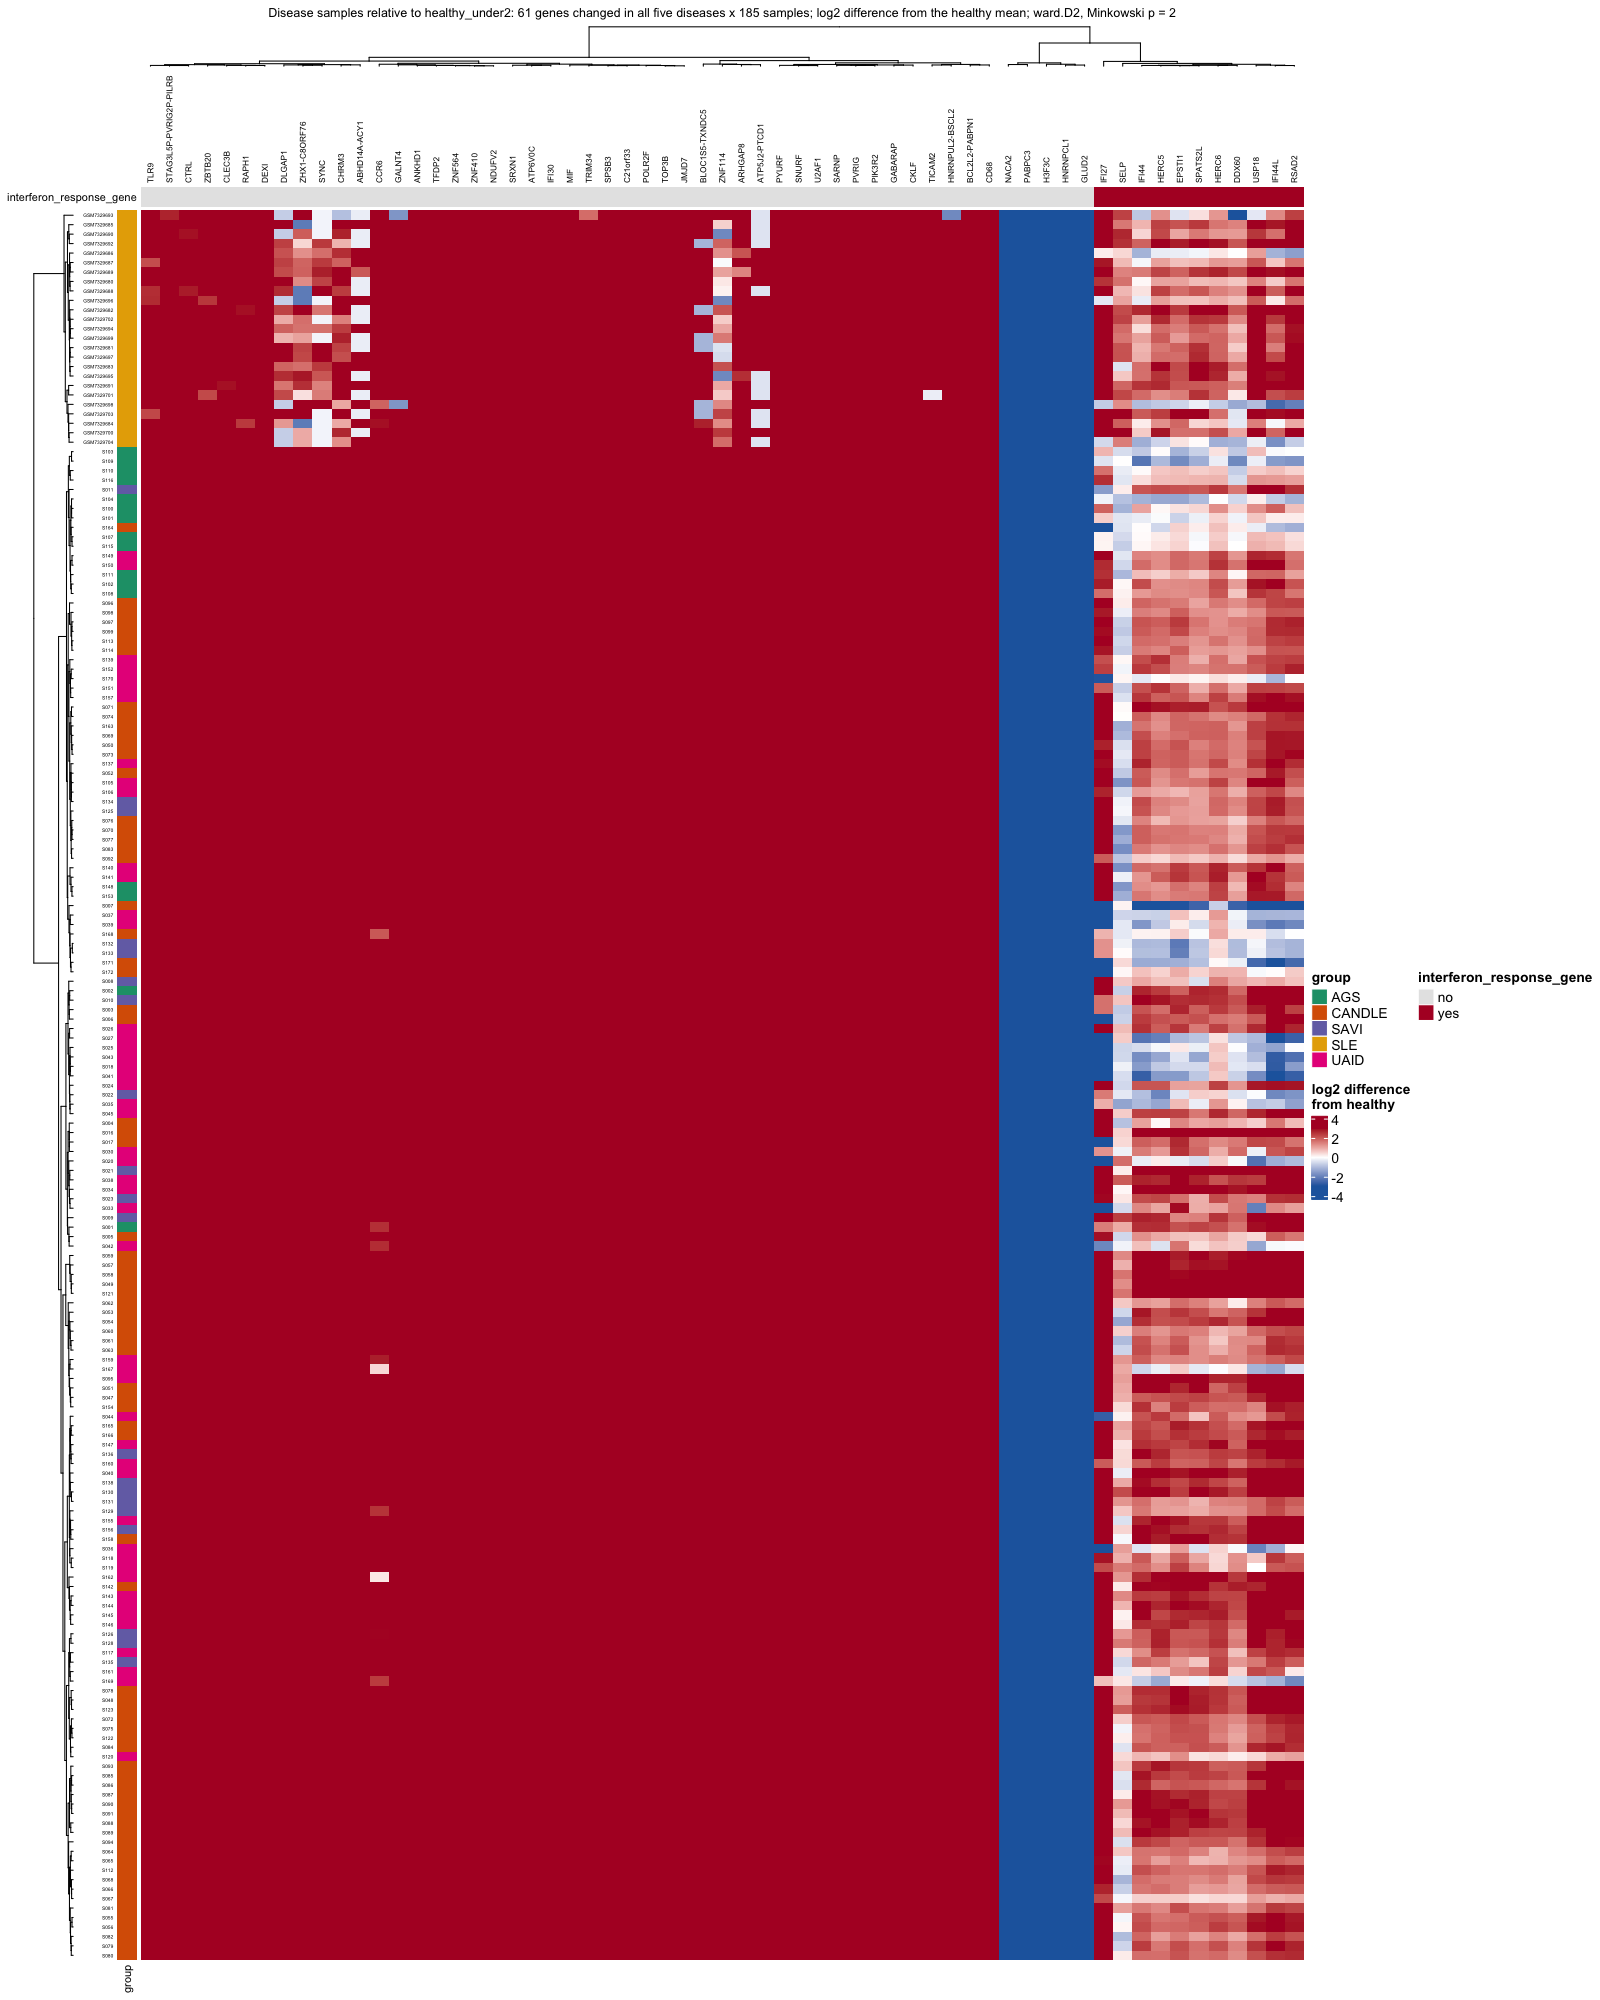

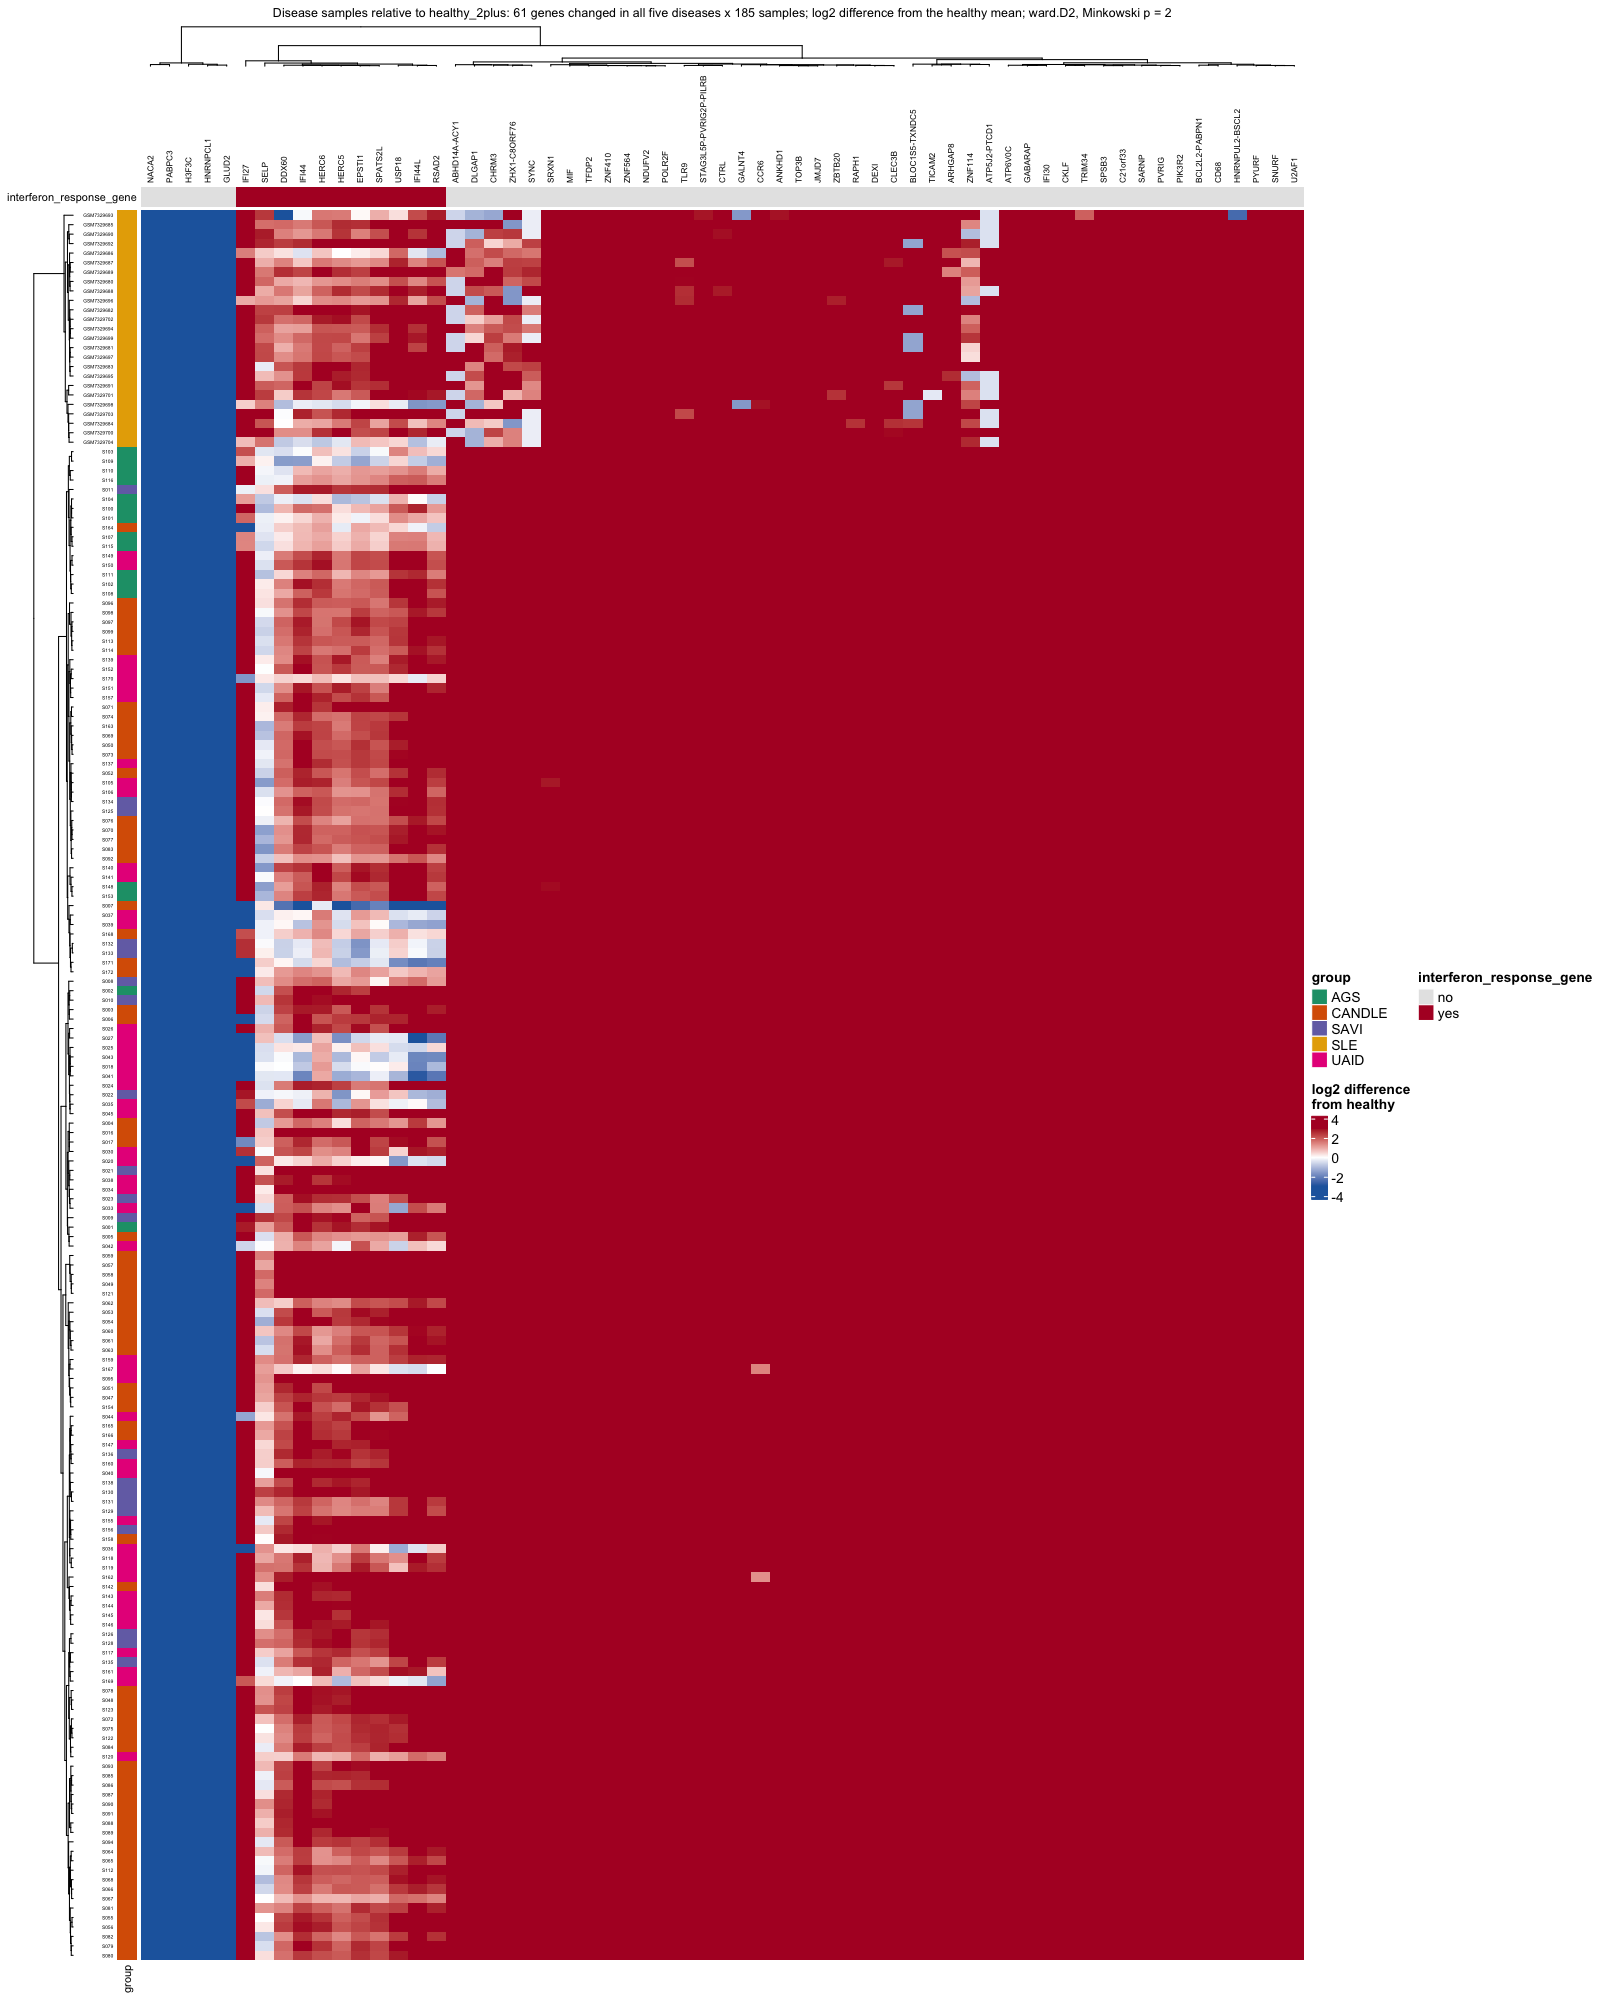

In [6]:
grp_col <- c(AGS = "#1B9E77", CANDLE = "#D95F02", SAVI = "#7570B3", UAID = "#E7298A", SLE = "#E6AB02")
left <- rowAnnotation(group = as.character(m$group[dzs]), col = list(group = grp_col), annotation_name_gp = gpar(fontsize = 8))
show_and_save <- function(ht, file, w, h) {
  for (res in c(300, 100)) {
    f <- if (res == 300) fig("CANDLE_SAVI", file) else tempfile(fileext = ".png")
    png(f, width = w, height = h, units = "in", res = res); draw(ht); invisible(dev.off())
  }
  IRdisplay::display_png(file = f)
}
show_genes <- head(genes_all5[order(-abs(rowMeans(rel$healthy_2plus)))], 50)
show_genes <- union(show_genes, intersect(genes_all5, a$ifn$gene_id))
for (h in hb) {
  R  <- t(rel[[h]][show_genes, ]); Rc <- pmin(pmax(R, -3), 3)
  hg <- hclust(dist(t(R), method = "minkowski", p = 2), method = "ward.D2")
  ifn_mark <- HeatmapAnnotation(interferon_response_gene = ifelse(colnames(R) %in% a$ifn$gene_id, "yes", "no"),
                                col = list(interferon_response_gene = c(yes = "#B2182B", no = "grey90")),
                                annotation_name_side = "left", annotation_name_gp = gpar(fontsize = 8))
  ht <- Heatmap(Rc, name = "log2 difference\nfrom healthy", col = colorRamp2(c(-3, 0, 3), c("#2166AC", "white", "#B2182B")),
                cluster_rows = hr, cluster_columns = hg, row_dend_side = "left", column_dend_side = "top",
                row_names_side = "left", row_names_gp = gpar(fontsize = 3.5), column_names_side = "top",
                column_labels = a$genes$gene_name[match(colnames(R), a$genes$gene_id)], column_names_gp = gpar(fontsize = 6),
                top_annotation = ifn_mark, left_annotation = left, column_title_gp = gpar(fontsize = 9),
                column_title = sprintf("Disease samples relative to %s: %d genes changed in all five diseases x %d samples; log2 difference from the healthy mean; ward.D2, Minkowski p = 2",
                                       h, ncol(R), nrow(R)))
  show_and_save(ht, sprintf("46b_patterns_vs_%s.png", h), 16, 20)
}

**Explanation**
- The heatmap shows, for each disease sample, the log2 difference from the healthy mean (red higher, blue lower
  than healthy; capped at -3 and 3), not z-scores, so that the colours read directly as "above or below
  healthy".
- `show_genes`: the 50 genes changed in all five diseases with the largest mean difference, plus any interferon
  response gene changed in all five; the strip on top marks the interferon response genes.
- Rows use the sample tree `hr`; columns a Ward tree of the genes. Sample codes and gene names are next to their
  trees. One heatmap per healthy block.

## References

1. Law CW, Chen Y, Shi W, Smyth GK. voom: precision weights unlock linear model analysis tools for RNA-seq read counts. *Genome Biol* 2014;15:R29.
2. Lex A, Gehlenborg N, Strobelt H, Vuillemot R, Pfister H. UpSet: visualization of intersecting sets. *IEEE Trans Vis Comput Graph* 2014;20:1983-1992.
3. Ward JH. Hierarchical grouping to optimize an objective function. *J Am Stat Assoc* 1963;58:236-244.
4. Murtagh F, Legendre P. Ward's hierarchical agglomerative clustering method: which algorithms implement Ward's criterion? *J Classif* 2014;31:274-295.
5. Gu Z, Eils R, Schlesner M. Complex heatmaps reveal patterns and correlations in multidimensional genomic data. *Bioinformatics* 2016;32:2847-2849.
6. Gu Z, Gu L, Eils R, Schlesner M, Brors B. circlize implements and enhances circular visualization in R. *Bioinformatics* 2014;30:2811-2812.
7. Kim H, et al. Development of a validated interferon score using NanoString technology. *J Interferon Cytokine Res* 2018;38:171-185.
8. de Jesus AA, et al. Distinct interferon signatures and cytokine patterns define additional systemic autoinflammatory diseases. *J Clin Invest* 2020;130:1669-1682.
9. DeBerg HA, et al. Shared and organism-specific host responses to childhood diarrheal diseases revealed by whole blood transcript profiling. *PLoS One* 2018;13:e0192082.
10. Chen YC, et al. Peripheral blood cells RNA-seq identifies differentially expressed gene network linked to lymphocyte subsets alterations and active lupus nephritis associated with declines in renal function. *Heliyon* 2024;10:e32303.
11. R Core Team. *R: A Language and Environment for Statistical Computing*. R Foundation for Statistical Computing, Vienna, Austria.